In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784")

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target, test_size=10000)

In [5]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
24646,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10608,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20416,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8124,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22317,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41569,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
from sklearn.ensemble import RandomForestClassifier
import time
rf_clf = RandomForestClassifier()

start = time.time()
print("Starting")
rf_clf.fit(X_train, y_train)
print("Took", time.time() - start, "s")

Starting
Took 31.602912664413452 s


In [12]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
52139,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
62060,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10050,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59574,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34518,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40704,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
from sklearn.metrics import accuracy_score

y_pred = rf_clf.predict(X_test)

print("Accuracy Score", accuracy_score(y_test, y_pred))

Accuracy Score 0.9702


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

start = time.time()
X_reduced = pca.fit_transform(X_train)
print("Took", time.time() - start, "s to transform")

X_reduced_train = pca.transform(X_test)

start = time.time()
rf_clf2 = RandomForestClassifier()
print("Starting to fit reduced training data")
rf_clf2.fit(X_reduced, y_train)
print("Fitted in", time.time() - start, "s")



y_pred = rf_clf2.predict(X_reduced_train)
print("Accuracy score with reduced training data", accuracy_score(y_test, y_pred))

Took 1.5927355289459229 s to transform
Starting to fit reduced training data
Fitted in 79.41895723342896 s
Accuracy score with reduced training data 0.9477


In [7]:
print(mnist.data.shape)
print(X_reduced.shape)

(70000, 784)


NameError: name 'X_reduced' is not defined

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
tsne = TSNE(n_components=2)
X_reduced = tsne.fit_transform(mnist.data)

X_reduced



array([[ 33.480503 ,   1.4690906],
       [ 69.15504  ,  38.057823 ],
       [ 35.1329   , -85.368935 ],
       ...,
       [ 12.944362 , -47.08401  ],
       [ 18.083155 , -23.165014 ],
       [ 62.59136  , -34.791817 ]], shape=(70000, 2), dtype=float32)

NameError: name 'X_train' is not defined

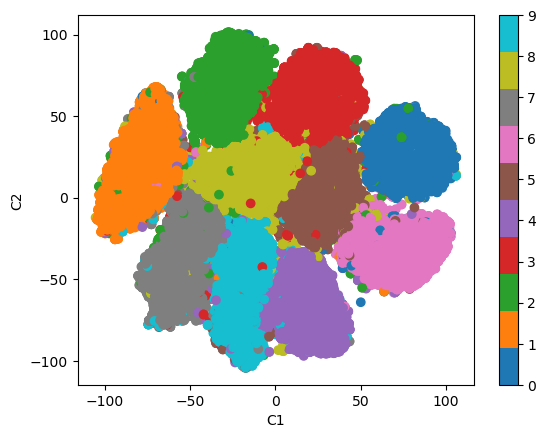

In [17]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=mnist.target.astype(int), cmap="tab10")
plt.colorbar()
plt.xlabel("C1")
plt.ylabel("C2")
plt.show()

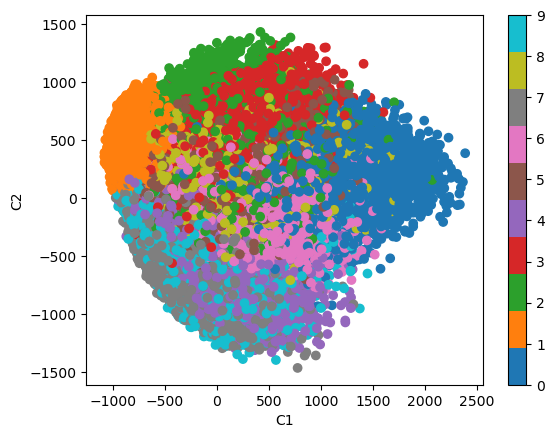

In [19]:
X_reduced = PCA(n_components=2).fit_transform(mnist.data)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=mnist.target.astype(int), cmap="tab10")
plt.colorbar()
plt.xlabel("C1")
plt.ylabel("C2")
plt.show()


In [ ]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2)
X_reduced = lle.fit_transform(mnist.data)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=mnist.target.astype(int), cmap="tab10")
plt.colorbar()
plt.xlabel("C1")
plt.ylabel("C2")
plt.show()

In [4]:
mnist.data.shape

(70000, 784)

In [3]:
from sklearn.manifold import MDS

mds = MDS(n_components=2)
X_reduced = mds.fit_transform(mnist.data)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=mnist.target.astype(int), cmap="tab10")
plt.colorbar()
plt.xlabel("C1")
plt.ylabel("C2")
plt.show()

/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


MemoryError: Unable to allocate 36.5 GiB for an array with shape (70000, 70000) and data type float64